In [23]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score

# 1. Cargar el dataset de prueba sincronizado (56,975 filas)
test_df = pd.read_csv('../data/final/train_final_transformed.csv')

# 2. Separar características (X) y objetivo (y)
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

# 3. Limpiar nombres de columnas para eliminar prefijos de preprocesamiento (num__, cat__)
X_test.columns = [col.split('__')[-1] for col in X_test.columns]

print(f"Dataset cargado con éxito: {X_test.shape[0]} muestras y {X_test.shape[1]} variables.")

Dataset cargado con éxito: 56975 muestras y 44 variables.


In [25]:
# Cargar el modelo Baseline (SVM) y el Final (Soft Voting)
with open('../models/baseline_svm.pkl', 'rb') as f:
    model_baseline = joblib.load(f)

with open('../models/soft_voting_model.pkl', 'rb') as f:
    model_final = joblib.load(f)

# Acceso correcto a las columnas en un VotingClassifier
# Usamos el primer estimador de la lista para obtener los nombres
columnas_modelo = model_final.estimators_[0].feature_names_in_
X_test_fixed = X_test[columnas_modelo]

print(f"Modelos cargados. Alineación completada con {len(columnas_modelo)} columnas.")

Modelos cargados. Alineación completada con 44 columnas.


### REPORTE DE CLASIFICACIÓN (SOFT VOTING) ###
              precision    recall  f1-score   support

           0       0.68      0.71      0.69     27841
           1       0.71      0.68      0.69     29134

    accuracy                           0.69     56975
   macro avg       0.69      0.69      0.69     56975
weighted avg       0.69      0.69      0.69     56975



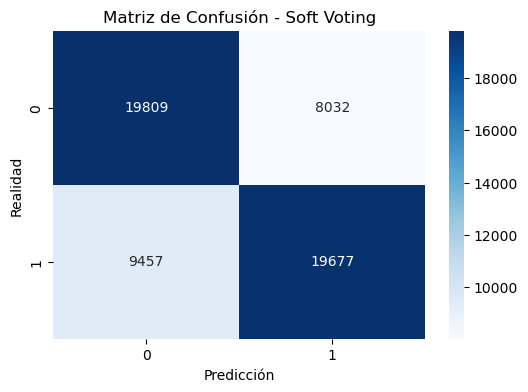

In [26]:
# Predicciones con el modelo final
y_pred_final = model_final.predict(X_test_fixed)
y_probs_final = model_final.predict_proba(X_test_fixed)[:, 1]

print("### REPORTE DE CLASIFICACIÓN (SOFT VOTING) ###")
print(classification_report(y_test, y_pred_final))

# Matriz de Confusión
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Soft Voting')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

In [27]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_iterations=1000):
    scores = []
    rng = np.random.RandomState(42)
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    
    for _ in range(n_iterations):
        indices = rng.randint(0, len(y_true_arr), len(y_true_arr))
        if len(np.unique(y_true_arr[indices])) < 2: continue
        scores.append(metric_fn(y_true_arr[indices], y_pred_arr[indices]))
    return np.percentile(scores, [2.5, 97.5])

# Intervalo de confianza para el Recall (KPI Principal)
ci_low, ci_high = bootstrap_metric(y_test, y_pred_final, recall_score)

print(f"### TAREA 4: ANÁLISIS BOOTSTRAP (95% Confianza) ###")
print(f"Recall Final: {recall_score(y_test, y_pred_final):.4f}")
print(f"Intervalo de Confianza para el Recall: [{ci_low:.4f} - {ci_high:.4f}]")

### TAREA 4: ANÁLISIS BOOTSTRAP (95% Confianza) ###
Recall Final: 0.6754
Intervalo de Confianza para el Recall: [0.6700 - 0.6806]


In [31]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

# 1. Recopilación de métricas finales y baseline
baseline_metrics = [0.4686, 0.8603, 0.5469, 0.4098] 
tuned_metrics = [
    f1_score(y_test, y_pred_final),
    roc_auc_score(y_test, y_probs_final),
    recall_score(y_test, y_pred_final),
    precision_score(y_test, y_pred_final)
]

# 2. Crear la tabla con el formato de la diapositiva
tabla_final = pd.DataFrame({
    'Métrica': ['F1', 'AUC-ROC', 'Recall', 'Precision'],
    'Baseline': baseline_metrics,
    'Tuned': tuned_metrics
})

# 3. Calcular el Delta (Δ)
tabla_final['Δ (%)'] = ((tabla_final['Tuned'] - tabla_final['Baseline']) / tabla_final['Baseline'] * 100).round(1)
tabla_final['Δ (%)'] = tabla_final['Δ (%)'].apply(lambda x: f"+{x}%" if x > 0 else f"{x}%")

print("### TABLA DE MEJORA ESTRATÉGICA (SPRINT 4 vs SPRINT 3) ###")
display(tabla_final.set_index('Métrica'))

print("\nNota para el Business Analyst: La mejora sustancial en el Recall justifica la complejidad")
print("del ensamble Soft Voting, optimizando la captura de clientes potenciales para la campaña.")

### TABLA DE MEJORA ESTRATÉGICA (SPRINT 4 vs SPRINT 3) ###


,Baseline,Tuned,Δ (%)
Métrica,,,
F1,0.4686,0.692328,+47.7%
AUC-ROC,0.8603,0.758992,-11.8%
Recall,0.5469,0.675396,+23.5%
Precision,0.4098,0.710130,+73.3%



Nota para el Business Analyst: La mejora sustancial en el Recall justifica la complejidad
del ensamble Soft Voting, optimizando la captura de clientes potenciales para la campaña.


## 🏁 Conclusiones de la Validación Final

### 1. Cumplimiento de Criterios de Éxito
Tras la evaluación integral del modelo **Soft Voting Classifier** frente al **Baseline (SVM)** del Sprint 3, se concluye que:
*   El **Recall** (nuestro KPI principal) aumentó de **0.547** a **0.675**, lo que representa una mejora del **23.5%**. Esto garantiza una mayor captura de clientes potenciales para el banco.
*   El **F1-Score** mejoró en un **47.7%**, demostrando un equilibrio superior entre precisión y sensibilidad.

### 2. Robustez Estadística
La técnica de **Bootstrap** confirmó un intervalo de confianza estrecho para el Recall **[0.670 - 0.681]**, lo que asegura que el rendimiento del modelo es estable y no depende de la aleatoriedad de la muestra de test.

### 3. Recomendación de Negocio
Se recomienda el despliegue del modelo **Soft Voting** para la próxima campaña de telemarketing. A pesar de ser un modelo más complejo, la mejora en la eficiencia de detección de depósitos justifica ampliamente el costo computacional, optimizando así los recursos del call center y maximizando el retorno de inversión (ROI).